In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import shap

# XGBoost

## Data Preprocessing

In [120]:
data = pd.read_csv("dataset_refining/german_credit_data_with_risk.csv")

# Missing values are present in "Checking account" and "Saving accounts". They directly link to 0$, hence we replace them with 0s
data = data.fillna(0)

# Using sex hurts model performance, while also adds unnecessary bias, so we remove it
data.drop(columns=["Sex"], inplace=True)

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    "domestic appliances": 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)

data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
data.replace({"Housing":          {"free": 0, "rent": 1, "own": 2}}, inplace=True)
data["credit_risk"] = data["credit_risk"].map({1: 1, 2: 0})   # good=1, bad=0

data = data.astype({
    "Saving accounts": "int",
    "Checking account": "int",
    "Housing": "int"
})

In [121]:
X = data.drop(columns=["credit_risk"])
y = data["credit_risk"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Training

In [140]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False);

## Global Results

In [141]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print("=" * 40)

  Accuracy : 0.8050
  F1 Score : 0.8696
  AUC      : 0.7805


In [142]:
n_rounds = model.n_estimators

acc_train, acc_test = [], []
f1_train,  f1_test  = [], []
auc_train, auc_test = [], []

for i in range(1, n_rounds + 1):
    # --- TRAIN ---
    y_proba_tr = model.predict_proba(X_train, iteration_range=(0, i))[:, 1]
    y_pred_tr  = (y_proba_tr >= 0.5).astype(int)

    acc_train.append(accuracy_score(y_train, y_pred_tr))
    f1_train.append(f1_score(y_train, y_pred_tr))
    auc_train.append(roc_auc_score(y_train, y_proba_tr))

    # --- TEST ---
    y_proba_te = model.predict_proba(X_test, iteration_range=(0, i))[:, 1]
    y_pred_te  = (y_proba_te >= 0.5).astype(int)

    acc_test.append(accuracy_score(y_test, y_pred_te))
    f1_test.append(f1_score(y_test, y_pred_te))
    auc_test.append(roc_auc_score(y_test, y_proba_te))

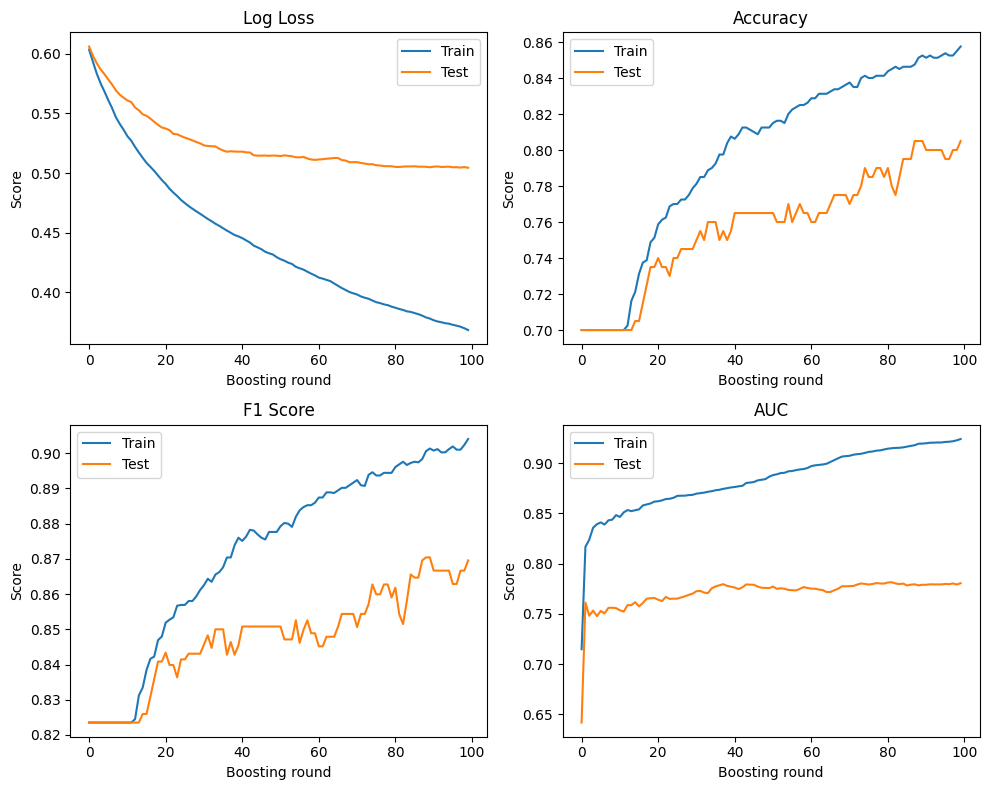

In [143]:
results = model.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss  = results["validation_1"]["logloss"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Logloss ---
axs[0, 0].plot(train_loss, label="Train")
axs[0, 0].plot(test_loss, label="Test")
axs[0, 0].set_title("Log Loss")
axs[0, 0].legend()

# --- Accuracy ---
axs[0, 1].plot(acc_train, label="Train")
axs[0, 1].plot(acc_test, label="Test")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# --- F1 ---
axs[1, 0].plot(f1_train, label="Train")
axs[1, 0].plot(f1_test, label="Test")
axs[1, 0].set_title("F1 Score")
axs[1, 0].legend()

# --- AUC ---
axs[1, 1].plot(auc_train, label="Train")
axs[1, 1].plot(auc_test, label="Test")
axs[1, 1].set_title("AUC")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

The loss and metrics are slightly lower on training set than on the test set, indicating mild overfitting, but test performance remains strong.

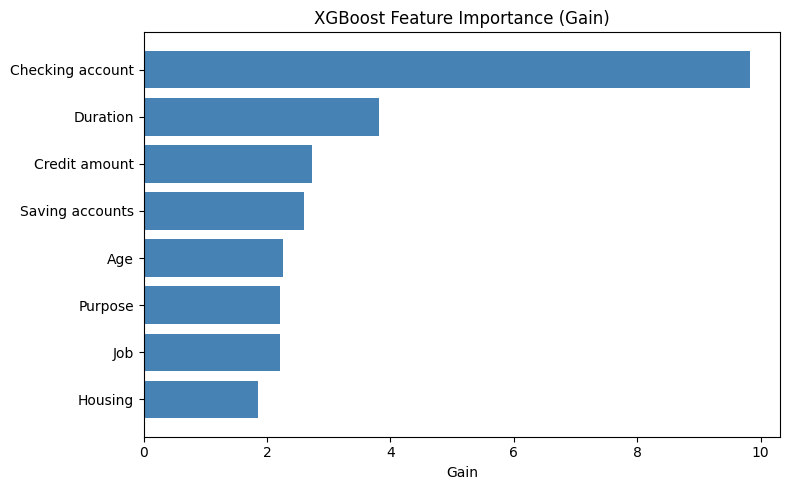

In [145]:
fig, ax = plt.subplots(figsize=(8, 5))
importance = model.get_booster().get_score(importance_type="gain")
importance = dict(sorted(importance.items(), key=lambda x: x[1]))
ax.barh(list(importance.keys()), list(importance.values()), color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

The feature importance plot shows that ‘Checking account’ contributes the most to model predictions, followed by ‘Duration’, ‘Saving accounts’, and ‘Credit amount’. Other features such as ‘Age’, ‘Purpose’, ‘Housing’, and ‘Job’ have moderate influence. This ranking aligns with expectations, as financial history and account balances are key factors in predicting credit risk.

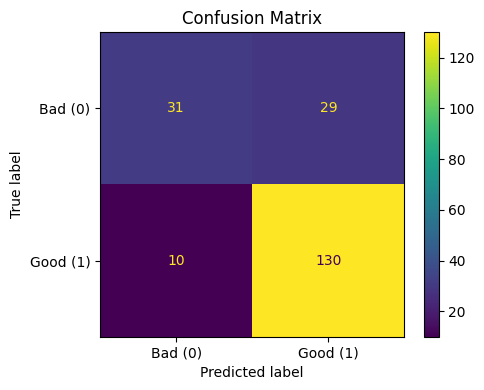

In [146]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Bad (0)", "Good (1)"], ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts most ‘Good’ cases (130/140) and a smaller portion of ‘Bad’ cases (31/60). Misclassifications occur mostly when a ‘Bad’ credit is predicted as ‘Good’ (28 cases). Overall, the model performs well, with better accuracy on the majority class (‘Good’), and mild overfitting does not appear to affect class separation significantly.

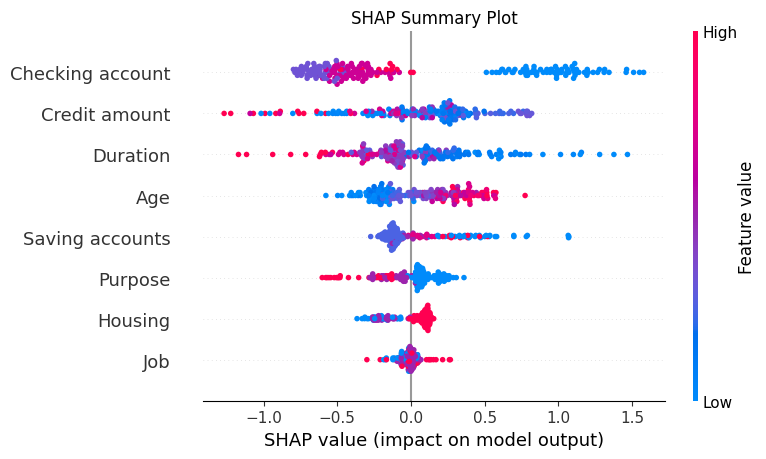

In [147]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

- **Checking account** - surprisingly, a value of `0` (no recorded checking account) contributes positively to good credit risk—likely reflecting individuals who maintain accounts in other banks or have alternative financial arrangements. Small or moderate balances are associated with higher risk, while high balances slightly increase predicted safety.
- **Credit amount** - values are not so well separated, but high values have a very clear negative impact while moderately low values a positive impact. Low values are around `0` likely because for someone with low credit, it is more likely that this low credit is all he can get.
- **Duration** - values in the middle are mixed up, but extremes tell the clear story, long = bad, short = good
- **Age** - Generally higher = better, with experience people generally advance their careers, build their own capital and have greater stability in life
- **Saving Accounts** - here 0 reffers to no saving account and it correlates positively with good risk maybe because those people invest their money outside banks and it serves them better, on the other hand people with rich saving accounts also score well which is obvious. Most people have little money on saving accounts and the model penalizes it slightly
- **Housing** - free or rented is a bad sign, own is a good sign because of greater stability
- **Purpose** - Here high and middle values reffer to ambitious and necessary purposes like school are repairs, it may be that people who take these loans are in a bad position in their life which correlates with bad risk, people who take their loans recklessly for cars and holidays are often in a more stable position
- **Job** - Generally better job is better (lower) credit risk

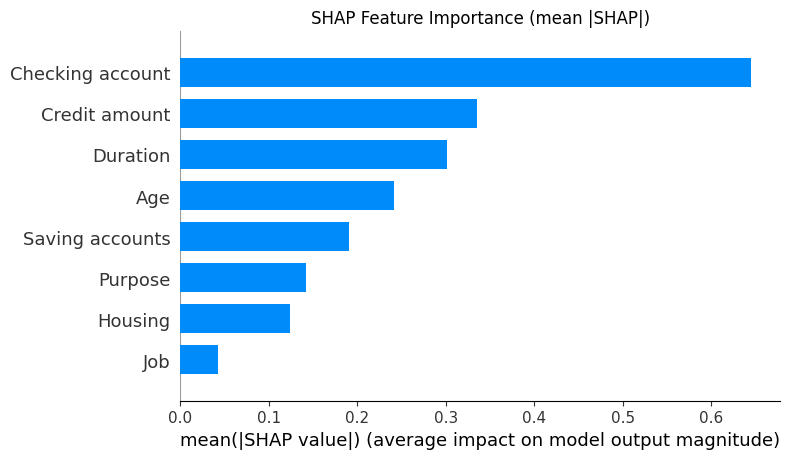

In [148]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

The SHAP feature importance shows that `Checking account` is by far the most influential feature, significantly exceeding all others. It is followed by `Credit amount` and `Duration`, indicating that the model relies primarily on financial attributes. `Age` and `Saving accounts` have moderate importance, while `Housing`, `Purpose`, and especially `Job` contribute relatively little to the model's predictions.

## Sample Analysis

In [360]:
from shapash.explainer.smart_explainer import SmartExplainer

# Create SmartExplainer
xpl = SmartExplainer(model=model)
xpl.compile(x=X_test, y_pred=model.predict(X_test))

# Visualize feature contribution for the sample
xpl.plot.contribution_plot(
    sample,  # single-row DataFrame
    title='Shapash Contribution'
)

# Optionally, display dashboard for multiple samples
# xpl.run_app()

ModuleNotFoundError: No module named 'shapash'

In [361]:
!pip install shapash

ERROR: Ignored the following versions that require a different python version: 1.0 Requires-Python >3.5,<3.8; 1.0.1 Requires-Python >3.5,<3.8; 1.1.0 Requires-Python >3.5,<3.9; 1.2.0 Requires-Python >3.5,<3.9; 1.3.1 Requires-Python >3.5,<3.9; 1.3.2 Requires-Python >3.5,<3.9; 1.4.0 Requires-Python >3.5,<=3.9; 1.4.1 Requires-Python >3.5,<=3.9; 1.4.2 Requires-Python >3.5,<3.10; 1.4.4 Requires-Python >3.5,<3.10; 1.5.0 Requires-Python >3.5,<3.10; 1.6.0 Requires-Python >3.5,<3.10; 1.6.1 Requires-Python >3.5,<3.10; 1.7.1 Requires-Python >3.5,<3.10; 2.0.0 Requires-Python >3.5,<3.10; 2.0.1 Requires-Python >3.5,<3.10; 2.0.2 Requires-Python >3.5,<3.10; 2.1.0 Requires-Python >3.6,<3.11; 2.1.1 Requires-Python >3.6,<3.11; 2.2.0 Requires-Python >3.6,<3.11; 2.2.1 Requires-Python >3.6,<3.11; 2.2.2 Requires-Python >3.6,<3.11; 2.3.0 Requires-Python >3.7,<3.11; 2.3.2 Requires-Python >3.7,<3.11; 2.3.3 Requires-Python >3.7,<3.11; 2.3.4 Requires-Python >3.7,<3.11; 2.3.5 Requires-Python >3.7,<3.11; 2.3.6 Requi

In [358]:
def plot_shap_waterfall(model, sample):
    # Ensure we have an explainer
    explainer = shap.TreeExplainer(model)

    # compute SHAP values for the sample
    shap_values = explainer.shap_values(sample)

    # get index 0 because it's a single-row DataFrame
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[0],
        feature_names=sample.columns,
        max_display=10
    )

    logit = explainer.expected_value + shap_values.sum()
    delta_logit = 0 - logit  # amount needed to flip class
    print(f"Amount needed to flip the class: {delta_logit:.4f}")

### Sample selection

In [342]:
# predicted probabilities for class 1 (Good)
probas = model.predict_proba(X_test)[:, 1]
preds  = model.predict(X_test)

idx_1 = 15
idx_2 = 71
idx_3 = 117

print(f"Probability {idx_1}:", probas[idx_1])
print(f"Probability {idx_2}:", probas[idx_2])
print(f"Probability {idx_3}:", probas[idx_3])

Probability 15: 0.5178642
Probability 71: 0.75202775
Probability 117: 0.7930926


In [351]:
# find samples closest to decision boundary (0.5)
distance = np.abs(probas - 0.5)

# exclude already selected index
distance[idx_good] = np.inf

idx_border = np.argmin(distance)

print("Borderline index:", idx_border)
print("Probability:", probas[idx_border])
print("True label:", y_test.iloc[idx_border])
print("Predicted:", preds[idx_border])

Borderline index: 79
Probability: 0.49987683
True label: 0
Predicted: 0


### Sample 15

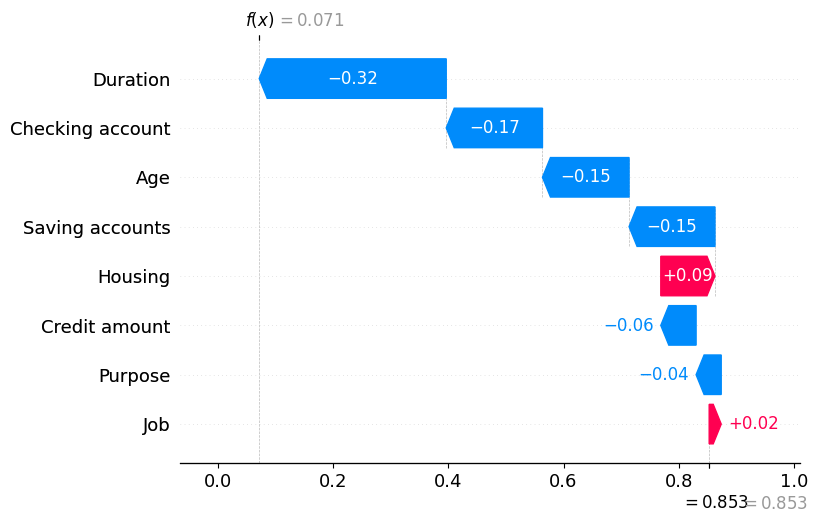

Amount needed to flip the class: -0.0715


In [359]:
plot_shap_waterfall(model, X_test.iloc[[15]])

In [347]:
sample = X_test.iloc[[15]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
248,26,2,2,1,3,1925,24,1


Checking account - the most influential attribute is quite high, by reducing it I 

In [352]:
sample['Checking account'] = 2

In [353]:
model.predict_proba(sample)

array([[0.57226884, 0.42773116]], dtype=float32)

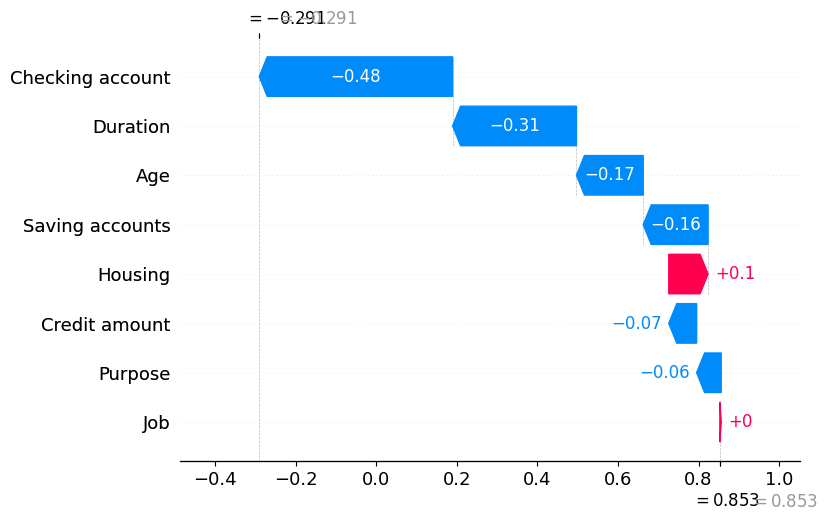

In [354]:
plot_shap_waterfall(model, sample)

In [285]:
top_idx = np.argsort(np.abs(contribs))[::-1]

for j in top_idx:
    print(feature_names[j], contribs[j], features.iloc[j])

Checking account 1.0630586 0
Age 0.5731507 49
Credit amount 0.496241 2331
Saving accounts 0.39326334 0
Purpose 0.1938756 0
Housing 0.10117088 2
Duration 0.075521804 12
Job 0.014370722 2


In [303]:
def find_continuous_flip(model, sample, col, current_class, a, b, tol=1e-3, max_iter=20):
    """Find minimal change to flip class probability below 0.5"""
    # Decide target probability threshold
    target = 0.5
    for _ in range(max_iter):
        mid = (a + b) / 2
        # safely assign value
        val = int(round(mid)) if np.issubdtype(sample[col].dtype, np.integer) else mid
        sample.loc[sample.index[0], col] = val
        
        prob = model.predict_proba(sample)[0, current_class]
        
        if abs(prob - target) < tol:
            return val  # probability close enough to 0.5
        elif prob > target:
            # still above threshold, need more change
            a = mid
        else:
            b = mid

    # fallback: take mid value
    return int(round(mid)) if np.issubdtype(sample[col].dtype, np.integer) else mid

In [304]:
def find_new_value(model, values, sample, current_class):
    col = sample.columns[0] if len(sample.columns) == 1 else sample.columns[-1]
    x_orig = sample.loc[sample.index[0], col]

    # Categorical
    if len(values) < 10:
        best_value = x_orig
        best_prob = model.predict_proba(sample)[0, current_class]

        for v in values:
            sample.loc[sample.index[0], col] = v
            prob = model.predict_proba(sample)[0, current_class]
            if (prob < 0.5 and prob > best_prob) or (prob >= 0.5 and prob < best_prob):
                best_prob = prob
                best_value = v

        sample.loc[sample.index[0], col] = x_orig
        return best_value

    # Continuous
    else:
        a, b = min(values), max(values)
        best_value = find_continuous_flip(model, sample, col, current_class, a, b)
        sample.loc[sample.index[0], col] = x_orig
        return best_value

In [311]:
def flip_prediction_shap(model, explainer, dataset, sample):
    sample = sample.copy()
    initial_values = sample.copy()

    # initial prediction and probabilities
    prob_bad_init, prob_good_init = model.predict_proba(sample).tolist()[0]
    start_class = 1 if prob_good_init >= 0.5 else 0
    current_class = start_class
    goal_class = 1 if prob_good_init < 0.5 else 0

    attributes = list(sample.columns)
    changed_attributes = []

    while current_class != goal_class:
        shap_values = explainer.shap_values(sample)[0]
        top_idx = np.argsort(np.abs(shap_values))[::-1]

        # pick the top SHAP attribute not yet changed
        for i in top_idx:
            if attributes[i] not in changed_attributes:
                changed_attributes.append(attributes[i])
                sample[attributes[i]] = find_new_value(
                    model,
                    dataset[attributes[i]].unique(),
                    sample,
                    current_class
                )
                break

        # update current prediction
        prob_bad, prob_good = model.predict_proba(sample).tolist()[0]
        current_class = 1 if prob_good >= 0.5 else 0

    # print old vs new feature values
    for a in changed_attributes:
        print(f"[{a}] - Old: {list(initial_values[a])[0]} | New: {list(sample[a])[0]}")

    # print old vs new probabilities
    prob_bad_final, prob_good_final = model.predict_proba(sample).tolist()[0]
    print(f"\nInitial prediction: {start_class}, probabilities: [bad: {prob_bad_init:.4f}, good: {prob_good_init:.4f}]")
    print(f"New prediction: {current_class}, probabilities: [bad: {prob_bad_final:.4f}, good: {prob_good_final:.4f}]")

    return sample

In [312]:
flip_prediction_shap(model, explainer, X_test, X_test.iloc[[111]])

[Checking account] - Old: 0 | New: 2
[Credit amount] - Old: 2331 | New: 15857

Initial prediction: 1, probabilities: [bad: 0.0227, good: 0.9773]
New prediction: 0, probabilities: [bad: 0.5090, good: 0.4910]


,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
356,49,2,2,0,2,15857,12,0


## Neural Network

In [ ]:
X

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Scale features (VERY important for NN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (reuse your split if already done)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [ ]:
model = MLP(input_dim=X_train.shape[1])

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    model.train()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model.eval()

with torch.no_grad():
    y_proba = model(X_test).numpy().flatten()

y_pred = (y_proba > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")